In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('../Datasets/clean_retail_sales_dataset.csv')
df

,Unnamed: 0,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [31]:
df["Date"] = pd.to_datetime(df["Date"],errors="coerce")

Top-selling products

In [32]:
top_selling_products =(
    df
    .groupby("Product Category", as_index=False)
    .agg(top_selling=("Quantity", "sum"))
    .sort_values("top_selling", ascending=False)
    .head(5)
)

top_selling_products

,Product Category,top_selling
1,Clothing,894
2,Electronics,849
0,Beauty,771


Revenue by product

In [33]:
product_revenue = (
    df
    .groupby("Product Category", as_index=False)
    .agg(revenue=("Total Amount", "sum"))
    .sort_values("revenue", ascending=False)
    .head(5)
)

product_revenue["revenue"] = product_revenue["revenue"].round(2)

product_revenue

,Product Category,revenue
2,Electronics,156905
1,Clothing,155580
0,Beauty,143515


Monthly sales trends

In [34]:
df["month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales =(
    df
    .groupby("month", as_index=False)
    .agg(monthly_sales=("Total Amount", "sum"))
    .sort_values("monthly_sales", ascending=False)
    .head(5)
)

monthly_sales["monthly_sales"] = monthly_sales["monthly_sales"].round(2)

monthly_sales

,month,monthly_sales
0,2023-10-01,46580
2,2023-12-01,44690
1,2023-11-01,34920


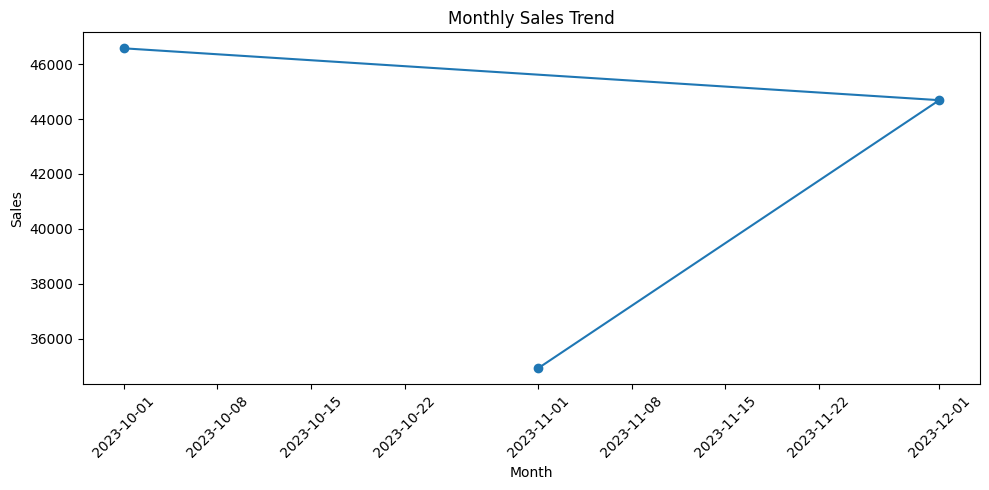

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["monthly_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top customers by spending

In [36]:
top_customer =(
    df
    .groupby(["Customer ID","Gender","Age"], as_index=False,dropna=False)
    .agg(total_spending=("Total Amount","sum"))
    .sort_values("total_spending", ascending=False)
)

top_customer["total_spending"] = top_customer["total_spending"].round(2)

top_customer

,Customer ID,Gender,Age,total_spending
946,CUST946,Male,62,2000
626,CUST626,Female,26,2000
634,CUST634,Male,60,2000
773,CUST773,Male,25,2000
420,CUST420,Female,22,2000
...,...,...,...,...
486,CUST486,Female,35,25
979,CUST979,Female,19,25
989,CUST989,Female,44,25
955,CUST955,Male,58,25


Which age group buys the most?

In [37]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[
        float("-inf"),
        24,
        40,
        55,
        float("inf")
    ],
    labels=[
        "under 25",
        "25-40",
        "41-55",
        "over 55"
    ]
)

age_group_summary =(
    df
    .groupby(
        "age_group",
        as_index=False,
        observed=True
    )
    .agg(
    total_revenue=("Total Amount", "sum"),
    total_orders=("Transaction ID","nunique"),
    total_customers=("Customer ID", "nunique"),
    total_items=("Quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

age_group_summary["total_revenue"] = (
    age_group_summary["total_revenue"].round(2)
)

print("\nSales by age group:")
print(age_group_summary)


Sales by age group:
  age_group  total_revenue  total_orders  total_customers  total_items
1     25-40         154245           317              317          820
2     41-55         146695           339              339          860
3   over 55          80410           195              195          468
0  under 25          74650           149              149          366


Average order value and quantity by product

In [38]:
average_order_value = (
    df
    .groupby("Product Category", as_index=False)
    .agg(
        avg_order_value=("Total Amount", "mean"),
        avg_quantity=("Quantity", "mean")
    )
    .sort_values("avg_order_value", ascending=False)
    .head(5)
)

average_order_value[
    ["avg_order_value", "avg_quantity"]
] = average_order_value[
    ["avg_order_value", "avg_quantity"]
].round(2)

print("\nAverage order-item value by product:")
print(average_order_value)


Average order-item value by product:
  Product Category  avg_order_value  avg_quantity
0           Beauty           467.48          2.51
2      Electronics           458.79          2.48
1         Clothing           443.25          2.55


monthly_sales forecasting

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
monthly_sales

,month,monthly_sales
0,2023-10-01,46580
2,2023-12-01,44690
1,2023-11-01,34920


Create Time Features

In [41]:
monthly_sales['year'] = monthly_sales['month'].dt.year
monthly_sales['month_num'] = monthly_sales['month'].dt.month

Create Training Data

In [42]:
x = monthly_sales[['year', 'month_num']]
y = monthly_sales['monthly_sales']

Train Model

In [43]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x,y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model Evaluation

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    shuffle=False,
    test_size=0.2
)

In [45]:
model.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(x_test)

mae = mean_absolute_error(
    y_test,
    pred
)

print(mae)

11225.300000000003
